# Lalonde CPS Synthetic DGP Application

This notebook uses the Lalonde-Dehejia-Wahba CPS comparison sample to illustrate the tabular simulation DGPs in Trex. It fits synthetic data generators to the observed CPS rows and then compares a simple regression-adjustment ATT estimate on the real and synthetic datasets.

The tensor models are fit locally:

- WGAN-GP, using the optimistic Adam option added for minimax training.
- DDPM-style tabular diffusion.

There is also an optional gpt-oss in-context-learning block. It assumes a local llama.cpp completion endpoint, for example the `gpt-oss` GGUF server in `~/tmp/llama-cpp`. The notebook does not add package dependencies for that path; it uses Python's standard-library HTTP client and skips the block unless the endpoint is running.

In [1]:
from __future__ import annotations

import csv
import json
import subprocess
import time
from pathlib import Path
from urllib.error import URLError
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from trex import TabularDiffusion, TabularTransformer, TabularWGAN, distribution_metrics

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

SEED = 20260526
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Load the CPS Sample

The notebook expects the numerical replication repository `evanmunro/dswgan-paper` next to Trex as `../dswgan-paper`. If it is missing, the loader clones it. The CPS sample combines the NSW treated units with CPS controls and is highly imbalanced in treatment status.

In [2]:
LDW_COLUMNS = [
    "t",
    "age",
    "education",
    "black",
    "hispanic",
    "married",
    "nodegree",
    "re74",
    "re75",
    "re78",
]
BINARY_COLUMNS = ["black", "hispanic", "married", "nodegree"]
NONNEGATIVE_COLUMNS = ["age", "education", "re74", "re75", "re78"]
COVARIATES = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75"]
OUTCOME = "re78"
TREATMENT = "t"

PAPER_REPO = Path("../dswgan-paper")
if not PAPER_REPO.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/evanmunro/dswgan-paper", str(PAPER_REPO)],
        check=True,
    )

DATA_PATH = PAPER_REPO / "data" / "original_data" / "cps_merged.feather"
real = pd.read_feather(DATA_PATH)[LDW_COLUMNS].astype(float)
real.describe().T

,count,mean,std,min,25%,50%,75%,max
t,16177.0,0.011436,0.106329,0.0,0.000,0.00,0.00,1.00
age,16177.0,33.140508,11.036508,16.0,24.000,31.00,42.00,55.00
education,16177.0,12.008283,2.868005,0.0,11.000,12.00,13.00,18.00
black,16177.0,0.082339,0.274889,0.0,0.000,0.00,0.00,1.00
hispanic,16177.0,0.071892,0.258317,0.0,0.000,0.00,0.00,1.00
married,16177.0,0.705755,0.455717,0.0,0.000,1.00,1.00,1.00
nodegree,16177.0,0.300550,0.458511,0.0,0.000,0.00,1.00,1.00
re74,16177.0,13880.469283,9613.114840,0.0,4075.275,14892.39,23491.61,35040.07
re75,16177.0,13512.213502,9313.206624,0.0,4103.419,14374.50,22830.19,25243.55
re78,16177.0,14749.482169,9670.995766,0.0,5492.710,16240.22,25564.67,60307.93


In [3]:
real[TREATMENT].value_counts().rename("count").to_frame().assign(share=lambda d: d["count"] / len(real))

,count,share
t,,
0.0,15992,0.988564
1.0,185,0.011436


## Regression-Adjustment Estimand

For each dataset, estimate the ATT by fitting the untreated outcome regression

$$
E[Y_i(0) \mid X_i] = X_i'\gamma
$$

on controls and predicting untreated earnings for treated units. The reported estimate is

$$
\hat\tau_{RA} = \frac{1}{n_1}\sum_{i:T_i=1} \{Y_i - X_i'\hat\gamma_0\}.
$$

This is intentionally simple: the point is to compare what the synthetic datasets imply for the same downstream estimator.

In [4]:
def design_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.column_stack([np.ones(len(df)), df[COVARIATES].to_numpy(dtype=float)])


def regression_adjustment_att(df: pd.DataFrame) -> dict[str, float | int | str]:
    data = df[LDW_COLUMNS].astype(float).copy()
    t = data[TREATMENT].to_numpy(dtype=int)
    y = data[OUTCOME].to_numpy(dtype=float)
    X = design_matrix(data)
    treated = t == 1
    control = t == 0
    if treated.sum() < 5 or control.sum() <= X.shape[1] + 1:
        return {
            "att_ra": np.nan,
            "se_treated_residual": np.nan,
            "n": len(data),
            "n_treated": int(treated.sum()),
            "n_control": int(control.sum()),
            "status": "insufficient treatment or control support",
        }
    beta0 = np.linalg.lstsq(X[control], y[control], rcond=None)[0]
    treated_effects = y[treated] - X[treated] @ beta0
    return {
        "att_ra": float(treated_effects.mean()),
        "se_treated_residual": float(treated_effects.std(ddof=1) / np.sqrt(treated.sum())),
        "n": len(data),
        "n_treated": int(treated.sum()),
        "n_control": int(control.sum()),
        "status": "ok",
    }


def make_result_row(name: str, df: pd.DataFrame) -> dict[str, float | int | str]:
    row = {"dataset": name}
    row.update(regression_adjustment_att(df))
    return row

make_result_row("real CPS", real)

{'dataset': 'real CPS',
 'att_ra': 689.8581362896974,
 'se_treated_residual': 598.4572421269324,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok'}

## Conditional Synthetic Generators

Treatment is rare in the CPS sample. Rather than ask an unconditional model to rediscover that small treated mass and then threshold a noisy generated `t`, the generators below condition on treatment status and generate the remaining columns. The synthetic datasets then reuse the empirical treatment vector in a random order.

This keeps the application centered on the distribution of covariates and outcomes given treatment status, which is what regression adjustment uses.

In [5]:
OUTPUT_DIR = Path("tmp/lalonde_cps_application")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_columns = [column for column in LDW_COLUMNS if column != TREATMENT]
feature_binary = [column for column in BINARY_COLUMNS if column in feature_columns]
feature_nonnegative = [column for column in NONNEGATIVE_COLUMNS if column in feature_columns]

features = real[feature_columns].copy()
context = real[[TREATMENT]].to_numpy(dtype=np.float32)
context_synth = rng.permutation(context, axis=0)

transformer = TabularTransformer(
    column_names=feature_columns,
    binary_columns=feature_binary,
    nonnegative_columns=feature_nonnegative,
).fit(features)
train_z = transformer.transform(features)
lower, upper = transformer.transformed_bounds()


def rebuild_dataset(generated_features: np.ndarray, generated_t: np.ndarray) -> pd.DataFrame:
    out = pd.DataFrame(generated_features, columns=feature_columns)
    out.insert(0, TREATMENT, generated_t.reshape(-1).astype(float))
    return out[LDW_COLUMNS].astype(float)


def postprocess_synthetic(df: pd.DataFrame) -> pd.DataFrame:
    out = df[LDW_COLUMNS].astype(float).copy()
    for col in [TREATMENT, *BINARY_COLUMNS]:
        out[col] = (np.clip(out[col], 0.0, 1.0) >= 0.5).astype(float)
    for col in NONNEGATIVE_COLUMNS:
        out[col] = np.maximum(out[col], 0.0)
    return out

### WGAN-GP

In [6]:
wgan_start = time.perf_counter()
wgan = TabularWGAN(
    hidden_dims=(64, 64),
    critic_hidden_dims=(64, 64),
    batch_size=512,
    max_steps=300,
    critic_steps=2,
    lr=1e-4,
    optimizer="optimistic_adam",
    gp_weight=5.0,
    binary_dims=transformer.binary_indices,
    lower_bounds=lower,
    upper_bounds=upper,
    seed=SEED,
    device=DEVICE,
)
wgan.fit(train_z, context=context)
wgan_z = wgan.sample(len(real), context=context_synth).numpy()
wgan_features = transformer.inverse_transform(wgan_z, random_state=SEED)
wgan_df = postprocess_synthetic(rebuild_dataset(wgan_features, context_synth))
wgan_seconds = time.perf_counter() - wgan_start
wgan_df.to_csv(OUTPUT_DIR / "cps_wgan_fake.csv", index=False)
make_result_row("WGAN-GP synthetic", wgan_df) | {"seconds": round(wgan_seconds, 2)}

/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'dataset': 'WGAN-GP synthetic',
 'att_ra': 286.49560649652847,
 'se_treated_residual': 116.92787262267754,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 4.36}

### DDPM-Style Tabular Diffusion

In [7]:
ddpm_start = time.perf_counter()
ddpm = TabularDiffusion(
    hidden_dims=(64, 64),
    n_timesteps=50,
    batch_size=512,
    max_steps=300,
    lr=1e-4,
    seed=SEED,
    device=DEVICE,
)
ddpm.fit(train_z, context=context)
ddpm_z = ddpm.sample(len(real), context=context_synth).numpy()
ddpm_features = transformer.inverse_transform(ddpm_z, random_state=SEED)
ddpm_df = postprocess_synthetic(rebuild_dataset(ddpm_features, context_synth))
ddpm_seconds = time.perf_counter() - ddpm_start
ddpm_df.to_csv(OUTPUT_DIR / "cps_ddpm_fake.csv", index=False)
make_result_row("DDPM synthetic", ddpm_df) | {"seconds": round(ddpm_seconds, 2)}

{'dataset': 'DDPM synthetic',
 'att_ra': -349.4156278332455,
 'se_treated_residual': 664.3333272333997,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 0.92}

### Optional gpt-oss ICL via llama.cpp

This block uses a local llama.cpp completion endpoint. If the gpt-oss server is not running, the notebook records that ICL was skipped. A typical server path on this machine is `~/tmp/llama-cpp` with a completion endpoint at `http://127.0.0.1:8080/completion`.

In [8]:
RUN_GPT_OSS_ICL = True
GPT_OSS_COMPLETION_URL = "http://127.0.0.1:8080/completion"
ICL_SAMPLE_SIZE = min(len(real), 1000)
ICL_ROWS_PER_PROMPT = 8
ICL_EXAMPLES = 24
ICL_MAX_ATTEMPTS = 160


def endpoint_available(url: str, timeout: float = 2.0) -> bool:
    health_url = url.rsplit("/", 1)[0] + "/health"
    try:
        with urlopen(health_url, timeout=timeout) as response:
            return response.status < 500
    except Exception:
        return False


def gptoss_prompt(training: pd.DataFrame, rows_requested: int, examples: int, seed: int) -> str:
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(training), min(examples, len(training)), replace=False)
    header = ",".join(LDW_COLUMNS)
    example_rows = "\n".join(
        ",".join(f"{value:.6g}" for value in training.iloc[i][LDW_COLUMNS].to_numpy(dtype=float))
        for i in idx
    )
    user_message = (
        f"Return only {rows_requested} numeric CSV rows. No prose.\n"
        f"Columns: {header}\n"
        "Examples:\n"
        f"{example_rows}\n"
        "CSV:\n"
    )
    return (
        "<|start|>system<|message|>"
        "You are a CSV generator for an econometric dataset. No reasoning. No prose."
        "<|end|><|start|>user<|message|>"
        f"{user_message}"
        "<|end|><|start|>assistant<|channel|>final<|message|>"
    )


def complete_llamacpp(prompt: str, url: str, max_new_tokens: int = 256, timeout: float = 240.0) -> str:
    payload = {
        "prompt": prompt,
        "n_predict": max_new_tokens,
        "temperature": 0.7,
        "stream": False,
        "cache_prompt": False,
        "stop": [],
    }
    request = Request(
        url,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urlopen(request, timeout=timeout) as response:
        body = json.loads(response.read().decode("utf-8"))
    if "content" in body:
        return str(body["content"])
    choices = body.get("choices")
    if isinstance(choices, list) and choices and "text" in choices[0]:
        return str(choices[0]["text"])
    raise RuntimeError(f"Unexpected completion response: {body}")


def parse_csv_rows(text: str) -> list[list[float]]:
    rows = []
    for line in text.splitlines():
        parts = [part.strip() for part in line.split(",")]
        if parts == LDW_COLUMNS or len(parts) != len(LDW_COLUMNS):
            continue
        try:
            rows.append([float(part) for part in parts])
        except ValueError:
            continue
    return rows


def sample_gptoss_icl() -> pd.DataFrame:
    rows = []
    attempts = 0
    while len(rows) < ICL_SAMPLE_SIZE and attempts < ICL_MAX_ATTEMPTS:
        attempts += 1
        requested = min(ICL_ROWS_PER_PROMPT, ICL_SAMPLE_SIZE - len(rows))
        prompt = gptoss_prompt(real, requested, ICL_EXAMPLES, SEED + attempts)
        text = complete_llamacpp(prompt, GPT_OSS_COMPLETION_URL)
        rows.extend(parse_csv_rows(text))
    if len(rows) < ICL_SAMPLE_SIZE:
        raise RuntimeError(f"Parsed {len(rows)} valid rows after {attempts} attempts.")
    df = pd.DataFrame(rows[:ICL_SAMPLE_SIZE], columns=LDW_COLUMNS)
    return postprocess_synthetic(df)


if RUN_GPT_OSS_ICL and endpoint_available(GPT_OSS_COMPLETION_URL):
    icl_start = time.perf_counter()
    gptoss_df = sample_gptoss_icl()
    gptoss_seconds = time.perf_counter() - icl_start
    gptoss_df.to_csv(OUTPUT_DIR / "cps_gptoss_icl_fake.csv", index=False)
    gptoss_status = make_result_row("gpt-oss ICL synthetic", gptoss_df) | {
        "seconds": round(gptoss_seconds, 2)
    }
else:
    gptoss_df = None
    gptoss_status = {
        "dataset": "gpt-oss ICL synthetic",
        "att_ra": np.nan,
        "se_treated_residual": np.nan,
        "n": 0,
        "n_treated": 0,
        "n_control": 0,
        "status": "skipped; llama.cpp gpt-oss completion endpoint was not reachable",
        "seconds": 0.0,
    }

gptoss_status

{'dataset': 'gpt-oss ICL synthetic',
 'att_ra': nan,
 'se_treated_residual': nan,
 'n': 0,
 'n_treated': 0,
 'n_control': 0,
 'status': 'skipped; llama.cpp gpt-oss completion endpoint was not reachable',
 'seconds': 0.0}

## ATT Estimates

In [9]:
datasets = {
    "real CPS": real,
    "WGAN-GP synthetic": wgan_df,
    "DDPM synthetic": ddpm_df,
}
if gptoss_df is not None:
    datasets["gpt-oss ICL synthetic"] = gptoss_df

att_table = pd.DataFrame([make_result_row(name, df) for name, df in datasets.items()])
if gptoss_df is None:
    att_table = pd.concat([att_table, pd.DataFrame([gptoss_status])], ignore_index=True)

att_table.to_csv(OUTPUT_DIR / "cps_att_estimates.csv", index=False)
att_table

,dataset,att_ra,se_treated_residual,n,n_treated,n_control,status,seconds
0,real CPS,689.858136,598.457242,16177,185,15992,ok,NaN
1,WGAN-GP synthetic,286.495606,116.927873,16177,185,15992,ok,NaN
2,DDPM synthetic,-349.415628,664.333327,16177,185,15992,ok,NaN
3,gpt-oss ICL synthetic,NaN,NaN,0,0,0,skipped; llama.cpp gpt-oss completion endpoint...,0.0


## Basic Distribution Diagnostics

The downstream ATT is the main application target here, but these diagnostics help detect obvious failures in the synthetic row distribution.

In [10]:
def metric_row(name: str, df: pd.DataFrame) -> dict[str, float | str]:
    metrics = distribution_metrics(real[LDW_COLUMNS].to_numpy(), df[LDW_COLUMNS].to_numpy(), seed=SEED)
    return {"dataset": name, **metrics}

metric_table = pd.DataFrame([
    metric_row("WGAN-GP synthetic", wgan_df),
    metric_row("DDPM synthetic", ddpm_df),
] + ([metric_row("gpt-oss ICL synthetic", gptoss_df)] if gptoss_df is not None else []))
metric_table.to_csv(OUTPUT_DIR / "cps_distribution_metrics.csv", index=False)
metric_table.round(4)

,dataset,marginal_w1_mean,marginal_w1_max,marginal_ks_mean,marginal_ks_max,mean_l2,cov_frobenius,corr_frobenius,sliced_wasserstein
0,WGAN-GP synthetic,2166.6329,7689.4079,0.3208,0.6703,7127.8639,2.218978e+08,3.5057,3591.4132
1,DDPM synthetic,590.8943,2298.5842,0.1726,0.3315,952.4809,1.519493e+08,2.5307,1660.9552


## Visual Check

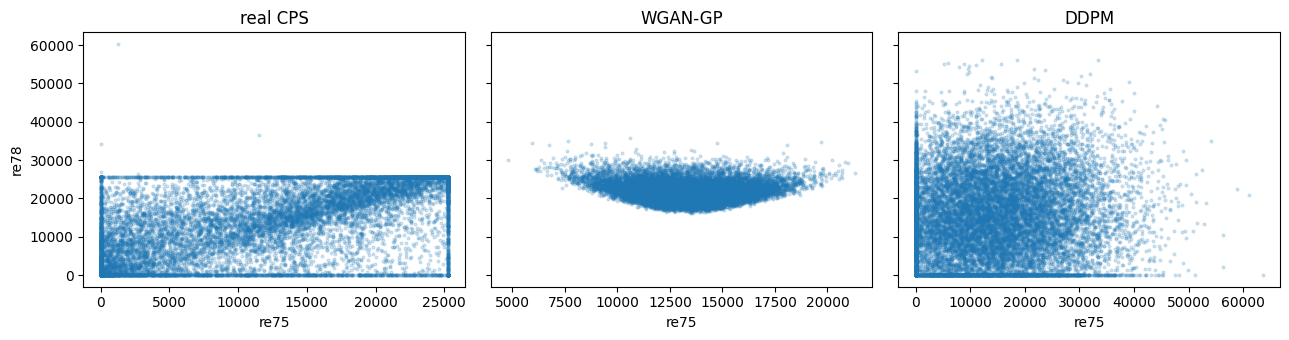

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
plot_items = [("real CPS", real), ("WGAN-GP", wgan_df), ("DDPM", ddpm_df)]
for ax, (title, df) in zip(axes, plot_items):
    ax.scatter(df["re75"], df["re78"], s=4, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("re75")
axes[0].set_ylabel("re78")
fig.tight_layout()
plt.show()

## Takeaways

This notebook is an application smoke test, not a final benchmark. The key workflow is:

1. Pull the CPS sample.
2. Fit treatment-conditional WGAN and DDPM row generators.
3. Optionally sample rows from a local gpt-oss llama.cpp completion endpoint.
4. Run the same regression-adjustment estimator on real and synthetic datasets.

The optional ICL path is deliberately kept outside the Trex package API. It is useful for one-off research comparison, but it depends on a separately managed local model server rather than a stable package dependency.